In [20]:
import sys
sys.path.append("../src")

from preprocessing import run_preprocessing_pipeline, build_feature_set, load_config
from modeling import run_purchase_prediction_pipeline, run_ltv_prediction_pipeline

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [21]:
cfg = load_config("../config/config.yaml")
df = run_preprocessing_pipeline(config_path="../config/config.yaml")
df.head()

로드 완료: 3024행 x 13열
전처리 완료. 경로: ../data/processed/processed_data.csv


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,HasPurchased,is_whale,session_bin,age_group
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,1,0,6-10,45-54
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,1,0,11-20,13-17
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,1,0,6-10,18-24
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,1,0,11-20,25-34
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,1,0,6-10,35-44


In [22]:
numeric_cols = ["Age", "SessionCount", "AverageSessionLength"]
categorical_cols = cfg["features"]["categorical"]

#### Whale 예측 (Logistic Regression + XGBoost)

In [23]:
df_enc, feature_cols, encoders = build_feature_set(df, numeric_cols, categorical_cols)
feature_cols

['Age',
 'SessionCount',
 'AverageSessionLength',
 'Gender_enc',
 'Device_enc',
 'GameGenre_enc',
 'Country_enc',
 'PaymentMethod_enc']

In [24]:
purchase_results = run_purchase_prediction_pipeline(df_enc, feature_cols, target_col="is_whale")


=== Logistic Regression 평가 결과 ===
              precision    recall  f1-score   support

   Non-Whale       0.98      0.58      0.72       591
       Whale       0.03      0.50      0.05        14

    accuracy                           0.57       605
   macro avg       0.50      0.54      0.39       605
weighted avg       0.96      0.57      0.71       605

ROC-AUC: 0.491
[WARN] AUC가 0.6 미만, 현재 피처셋만으로는 결제 행동을 안정적으로 설명하지 못함. 피처 추가 또는 데이터 수집 전략 재검토 필요.

=== XGBoost 평가 결과 ===
              precision    recall  f1-score   support

   Non-Whale       0.98      0.99      0.98       591
       Whale       0.00      0.00      0.00        14

    accuracy                           0.96       605
   macro avg       0.49      0.49      0.49       605
weighted avg       0.95      0.96      0.96       605

ROC-AUC: 0.539
[WARN] AUC가 0.6 미만, 현재 피처셋만으로는 결제 행동을 안정적으로 설명하지 못함. 피처 추가 또는 데이터 수집 전략 재검토 필요.


#### 임계값 조정으로 Whale Recall 개선

In [25]:
X = df_enc[feature_cols]
y = df_enc["is_whale"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    scale_pos_weight=scale,
    max_depth=4, n_estimators=200,
    random_state=42, eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_prob = xgb.predict_proba(X_test)[:, 1]

In [27]:
thresholds = np.arange(0.01, 0.5, 0.01)
best_thresh, best_f1 = 0, 0
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, pred, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"최적 임계값: {best_thresh:.2f}  |  Whale F1: {best_f1:.3f}")
print()

최적 임계값: 0.02  |  Whale F1: 0.022



In [28]:
y_pred_best = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_best, target_names=["Non-Whale", "Whale"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

              precision    recall  f1-score   support

   Non-Whale       0.98      0.87      0.92       591
       Whale       0.01      0.07      0.02        14

    accuracy                           0.86       605
   macro avg       0.49      0.47      0.47       605
weighted avg       0.95      0.86      0.90       605

ROC-AUC: 0.539


#### SMOTE 오버샘플링 + 임계값 최적화

In [29]:
from imblearn.over_sampling import SMOTE

X = df_enc[feature_cols]
y = df_enc["is_whale"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE 전 - Non-Whale: {(y_train==0).sum()}, Whale: {(y_train==1).sum()}")
print(f"SMOTE 후 - Non-Whale: {(y_train_res==0).sum()}, Whale: {(y_train_res==1).sum()}")
print()

SMOTE 전 - Non-Whale: 2365, Whale: 54
SMOTE 후 - Non-Whale: 2365, Whale: 2365



In [31]:
xgb_smote = XGBClassifier(
    max_depth=4, n_estimators=200,
    random_state=42, eval_metric='logloss'
)
xgb_smote.fit(X_train_res, y_train_res)
y_prob = xgb_smote.predict_proba(X_test)[:, 1]

In [32]:
thresholds = np.arange(0.01, 0.9, 0.01)
best_thresh, best_f1 = 0, 0
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, pred, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"임계값: {best_thresh:.2f}  |  Whale F1: {best_f1:.3f}")
print()
y_pred_best = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_best, target_names=["Non-Whale", "Whale"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

임계값: 0.07  |  Whale F1: 0.062

              precision    recall  f1-score   support

   Non-Whale       0.98      0.81      0.89       591
       Whale       0.04      0.29      0.06        14

    accuracy                           0.80       605
   macro avg       0.51      0.55      0.48       605
weighted avg       0.96      0.80      0.87       605

ROC-AUC: 0.547


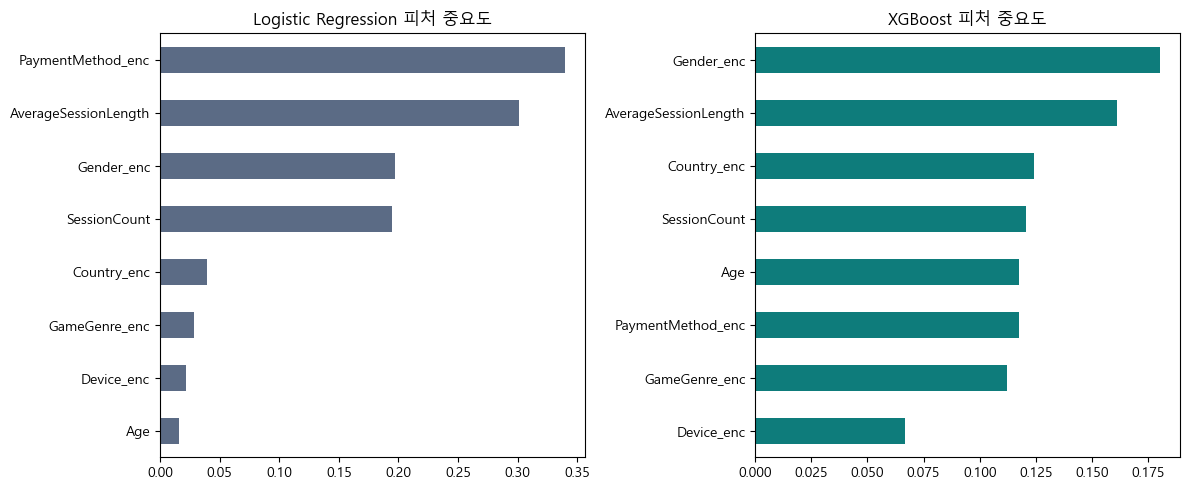

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

purchase_results["logistic"]["importance"].plot(kind="barh", ax=axes[0], color="#5B6B85")
axes[0].set_title("Logistic Regression 피처 중요도")
axes[0].invert_yaxis()

purchase_results["xgboost"]["importance"].plot(kind="barh", ax=axes[1], color="#0E7C7B")
axes[1].set_title("XGBoost 피처 중요도")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

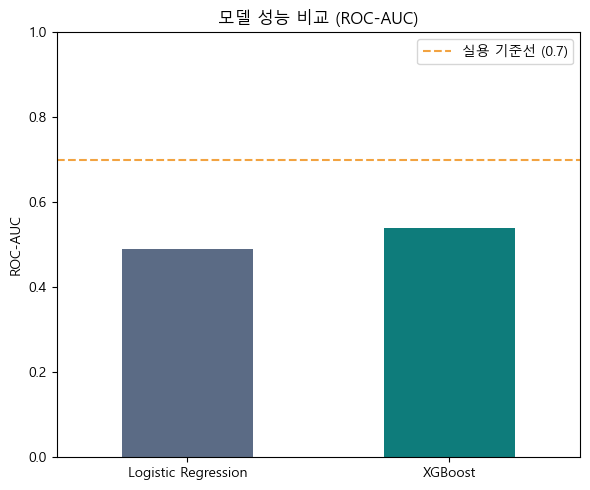

In [34]:
auc_compare = pd.Series({
    "Logistic Regression": purchase_results["logistic"]["auc"],
    "XGBoost": purchase_results["xgboost"]["auc"],
})
auc_compare.plot(kind="bar", color=["#5B6B85", "#0E7C7B"], figsize=(6, 5))
plt.title("모델 성능 비교 (ROC-AUC)")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.axhline(0.7, color="#F2A341", linestyle="--", label="실용 기준선 (0.7)")
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### LTV 예측 (XGBoost Regressor)

In [35]:
ltv_results = run_ltv_prediction_pipeline(df_enc, feature_cols, target_col="InAppPurchaseAmount")


=== XGBoost LTV Regressor 평가 결과 ===
MAE: 229.30
R2: -0.810
실제 평균 구매액: 90.30 / 예측 평균: 132.04
[WARN] R2가 음수. 현재 모델이 단순 평균값 예측보다도 성능이 낮음. 피처셋 재검토를 권장.


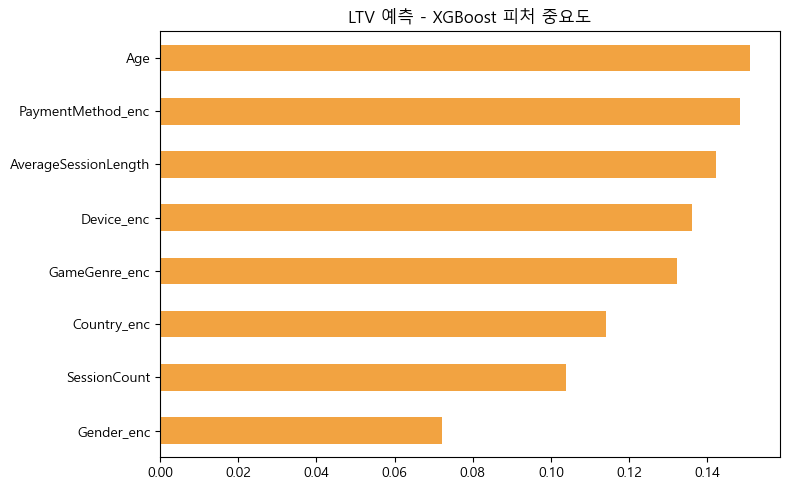

In [36]:
ltv_results["importance"].plot(kind="barh", color="#F2A341", figsize=(8, 5))
plt.title("LTV 예측 - XGBoost 피처 중요도")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()